# Phase 1: Exploratory Data Analysis & Problem Framing
**Objective:** Before building predictive models or merging complex exogenous variables, we must establish a baseline understanding of the historical Walmart sales data. In this phase, we will identify structural missing values and visualize the macroeconomic demand shocks that justify using Deep Learning (LSTM) over standard linear models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set visual styling for professional reporting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab10")

# 1. Load the core training data (Target Variable)
try:
    train_df = pd.read_csv('../data/train.csv')
    print(f"Target Data Successfully Loaded. Shape: {train_df.shape}")
except FileNotFoundError:
    print("Error: Ensure train.csv is in the 'data/' directory.")

# Display the raw structure
train_df.head()

Target Data Successfully Loaded. Shape: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Structural Integrity & Missing Data Check
A critical step in building a resilient data pipeline is identifying null values that could crash our inference engine in production.

In [3]:
print("--- Data Types ---")
print(train_df.info())

print("\n--- Missing Values in Core Data ---")
print(train_df.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(train_df.describe().T)

--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 17.3 MB
None

--- Missing Values in Core Data ---
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
Store,421570.0,22.200546,12.785297,1.00,11.00,22.00,33.0000,45.00
Dept,421570.0,44.260317,30.492054,1.00,18.00,37.00,74.0000,99.00
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.94,2079.65,7612.03,20205.8525,693099.36


*Observation: The core `train.csv` is clean, but later when we merge the `features.csv` (which contains Promotional Markdowns), we will encounter massive missing data blocks that need to be imputed with zeroes to represent non-promotional weeks.*

## Visualizing the Business Problem: Demand Shocks
If retail demand was a flat, linear line, we could use a simple Moving Average. We need to visualize the aggregate weekly sales to identify the non-linear, seasonal shocks (holidays, weather events) that require advanced time-series architectures.

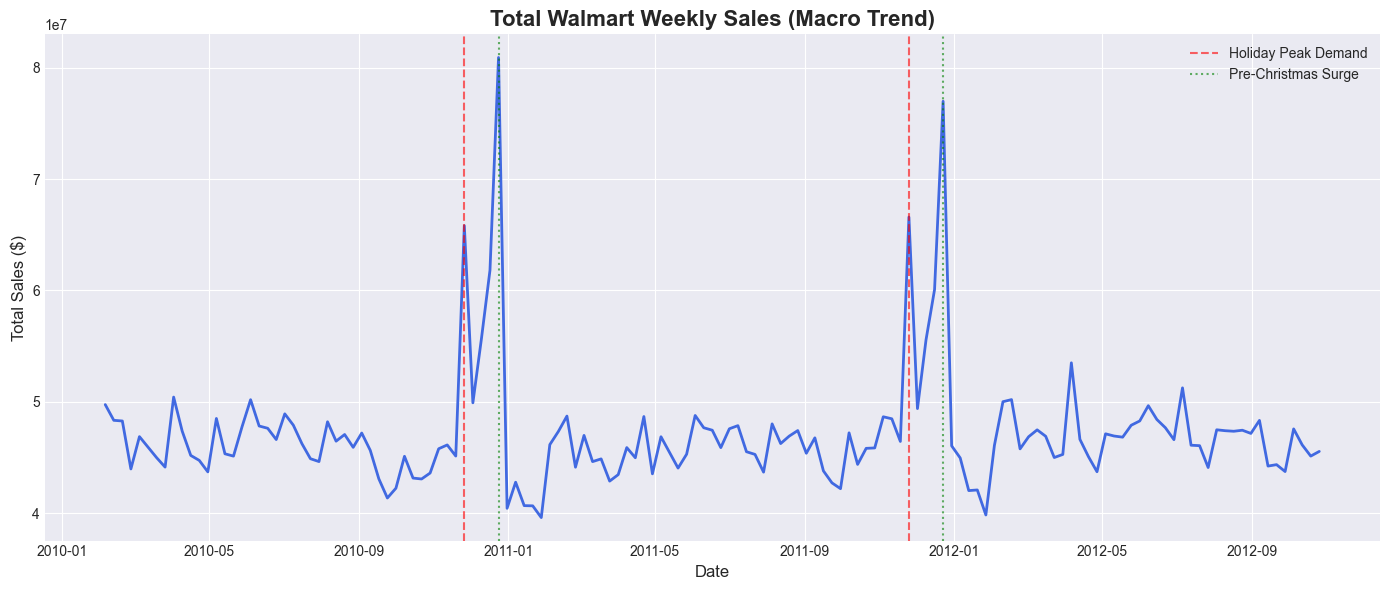

In [4]:
# Convert Date to datetime object for visualization
train_df['Date'] = pd.to_datetime(train_df['Date'])

# Group by Date to see the macro trend across all Walmart stores
weekly_sales = train_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Plot the macro trend
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'], color='royalblue', linewidth=2)
plt.title('Total Walmart Weekly Sales (Macro Trend)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Highlight known massive spikes (Thanksgiving / Black Friday / Christmas)
# (Adjust dates slightly based on the exact years in your dataset)
plt.axvline(pd.to_datetime('2010-11-26'), color='red', linestyle='--', alpha=0.6, label='Holiday Peak Demand')
plt.axvline(pd.to_datetime('2011-11-25'), color='red', linestyle='--', alpha=0.6)
plt.axvline(pd.to_datetime('2010-12-24'), color='green', linestyle=':', alpha=0.6, label='Pre-Christmas Surge')
plt.axvline(pd.to_datetime('2011-12-23'), color='green', linestyle=':', alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

### Phase 1 Conclusion
The visualization unequivocally proves that Walmart's demand is highly volatile and non-linear. Massive, recurring spikes dictate the revenue cycle. 

A standard statistical model operating purely on past sales will systematically under-predict these peaks, leading to **Stock-Outs** and lost revenue. 

**Next Steps (Phase 2):** We will transition to feature engineering, merging exogenous weather and store data to provide our models with the multivariate signals necessary to anticipate these demand shocks.